# Fase 6 — Verificación de resultados y modelo

Lee métricas desde logs y archivos guardados, sin necesidad de reentrenar.

**Checks:**
1. Cargar historial y ver métricas finales
2. Curvas de entrenamiento desde logs
3. Cargar modelo con mejores pesos
4. Predicciones sobre muestras reales
5. Diagonal: valores predichos vs reales

## 0. Setup

In [1]:
import sys
import os
import json
sys.path.append('/app')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

gpus = tf.config.list_physical_devices('GPU')
print('GPUs disponibles:', gpus)
print('✅ GPU OK' if gpus else '⚠️  Sin GPU')

from config import (
    CHECKPOINTS, LOGS, VISUALIZATIONS,
    BATCH_SIZE, EMB_OUTPUT_DIM, FORECAST_HORIZON
)
os.makedirs(VISUALIZATIONS, exist_ok=True)

2026-04-16 02:56:10.599874: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 02:56:10.600006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 02:56:10.646266: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4070 Laptop GPU, compute capability 8.9
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU OK


## 1. Historial de entrenamiento

In [2]:
# ── Opción A: desde history.json ──────────────────────────────────────────
history_path = str(LOGS / 'history.json')

if os.path.exists(history_path):
    with open(history_path) as f:
        histories = json.load(f)
    h1 = histories['phase1']
    h2 = histories['phase2']
    print('✅ Historial cargado desde history.json')
    print(f'  Fase 1: {len(h1["loss"])} épocas')
    print(f'  Fase 2: {len(h2["loss"])} épocas')
else:
    print('⚠️  history.json no encontrado — usando logs de TensorBoard')
    h1, h2 = None, None

✅ Historial cargado desde history.json
  Fase 1: 54 épocas
  Fase 2: 21 épocas


In [3]:
# ── Opción B: desde logs de TensorBoard ───────────────────────────────────
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tb_logs(log_dir: str) -> dict:
    ea = EventAccumulator(log_dir)
    ea.Reload()
    metrics = {}
    for tag in ea.Tags().get('scalars', []):
        events = ea.Scalars(tag)
        metrics[tag] = {
            'step':  [e.step  for e in events],
            'value': [e.value for e in events],
        }
    return metrics

tb_p1, tb_p2 = {}, {}
log_dir_p1 = str(LOGS / 'phase1')
log_dir_p2 = str(LOGS / 'phase2')

if os.path.exists(log_dir_p1):
    tb_p1 = load_tb_logs(log_dir_p1)
    print(f'✅ Logs Fase 1 cargados — métricas: {list(tb_p1.keys())}')
else:
    print('⚠️  No se encontraron logs de Fase 1')

if os.path.exists(log_dir_p2):
    tb_p2 = load_tb_logs(log_dir_p2)
    print(f'✅ Logs Fase 2 cargados — métricas: {list(tb_p2.keys())}')
else:
    print('⚠️  No se encontraron logs de Fase 2')

✅ Logs Fase 1 cargados — métricas: []
✅ Logs Fase 2 cargados — métricas: []


In [4]:
# Resumen numérico de métricas finales
def get_values(source, key, use_tb=False):
    if use_tb:
        return source.get(key, {}).get('value', [])
    return source.get(key, []) if source else []

use_tb = h1 is None
src1   = tb_p1 if use_tb else h1
src2   = tb_p2 if use_tb else h2

ssim1 = get_values(src1, 'val_ssim_metric', use_tb)
ssim2 = get_values(src2, 'val_ssim_metric', use_tb)
loss1 = get_values(src1, 'val_loss', use_tb)
loss2 = get_values(src2, 'val_loss', use_tb)

print('══════════════════════════════════════════════')
print('  Resumen de entrenamiento')
print('══════════════════════════════════════════════')
if ssim1:
    print(f'  Fase 1 — épocas      : {len(ssim1)}')
    print(f'  Fase 1 — mejor SSIM  : {max(ssim1):.4f}  (época {ssim1.index(max(ssim1))+1})')
    print(f'  Fase 1 — mejor loss  : {min(loss1):.4f}')
if ssim2:
    print(f'  Fase 2 — épocas      : {len(ssim2)}')
    print(f'  Fase 2 — mejor SSIM  : {max(ssim2):.4f}  (época {ssim2.index(max(ssim2))+1})')
    print(f'  Fase 2 — mejor loss  : {min(loss2):.4f}')
print('══════════════════════════════════════════════')

══════════════════════════════════════════════
  Resumen de entrenamiento
══════════════════════════════════════════════
  Fase 1 — épocas      : 54
  Fase 1 — mejor SSIM  : 0.6507  (época 33)
  Fase 1 — mejor loss  : 0.2939
  Fase 2 — épocas      : 21
  Fase 2 — mejor SSIM  : 0.6495  (época 1)
  Fase 2 — mejor loss  : 0.2935
══════════════════════════════════════════════


## 2. Curvas de entrenamiento

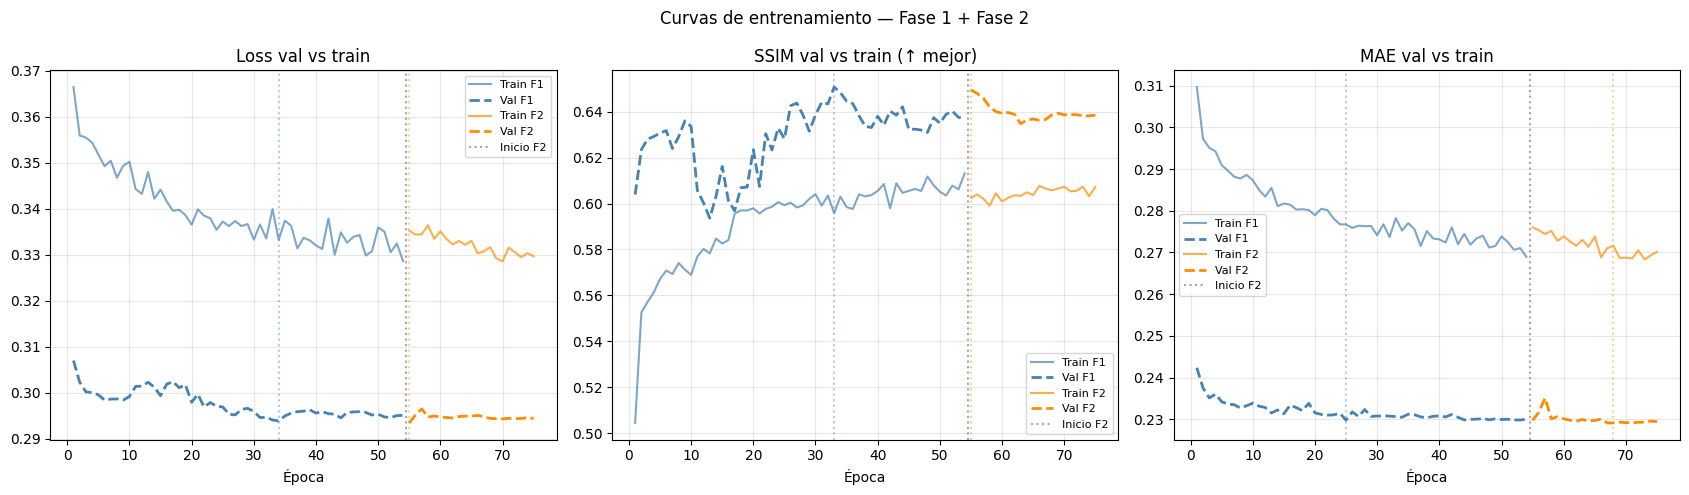

Guardado en /app/outputs/visualizations/fase6_curvas.png


In [5]:
def plot_curves(src1, src2, use_tb=False):
    metrics = [
        ('val_loss',        'loss',        'Loss val vs train'),
        ('val_ssim_metric', 'ssim_metric', 'SSIM val vs train (↑ mejor)'),
        ('val_mae_diagonal_metric',  'mae_diagonal_metric',  'MAE val vs train'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle('Curvas de entrenamiento — Fase 1 + Fase 2', fontsize=12)

    for ax, (val_key, train_key, title) in zip(axes, metrics):
        v1 = get_values(src1, val_key,   use_tb)
        t1 = get_values(src1, train_key, use_tb)
        v2 = get_values(src2, val_key,   use_tb)
        t2 = get_values(src2, train_key, use_tb)

        x1 = range(1, len(v1)+1)
        x2 = range(len(v1)+1, len(v1)+len(v2)+1)

        if t1: ax.plot(x1, t1, color='steelblue',  label='Train F1', alpha=0.7)
        if v1: ax.plot(x1, v1, color='steelblue',  label='Val F1',   linestyle='--', linewidth=2)
        if t2: ax.plot(x2, t2, color='darkorange', label='Train F2', alpha=0.7)
        if v2: ax.plot(x2, v2, color='darkorange', label='Val F2',   linestyle='--', linewidth=2)

        if v1 and v2:
            ax.axvline(x=len(v1)+0.5, color='gray', linestyle=':', alpha=0.7, label='Inicio F2')

        # Marcar mejor época
        if v1:
            best_idx = v1.index(max(v1)) if 'ssim' in val_key else v1.index(min(v1))
            ax.axvline(x=best_idx+1, color='steelblue', linestyle=':', alpha=0.4)
        if v2:
            best_idx2 = v2.index(max(v2)) if 'ssim' in val_key else v2.index(min(v2))
            ax.axvline(x=len(v1)+best_idx2+1, color='darkorange', linestyle=':', alpha=0.4)

        ax.set_title(title)
        ax.set_xlabel('Época')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    path = str(VISUALIZATIONS / 'fase6_curvas.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')

plot_curves(src1, src2, use_tb)

In [6]:
# Curva de LR si está disponible
lr1 = get_values(src1, 'lr', use_tb)
lr2 = get_values(src2, 'lr', use_tb)

if lr1 or lr2:
    fig, ax = plt.subplots(figsize=(10, 3))
    x1 = range(1, len(lr1)+1)
    x2 = range(len(lr1)+1, len(lr1)+len(lr2)+1)
    if lr1: ax.semilogy(x1, lr1, color='steelblue',  label='LR Fase 1')
    if lr2: ax.semilogy(x2, lr2, color='darkorange', label='LR Fase 2')
    if lr1 and lr2:
        ax.axvline(x=len(lr1)+0.5, color='gray', linestyle=':', alpha=0.7)
    ax.set_title('Learning Rate por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('LR (escala log)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(VISUALIZATIONS / 'fase6_lr.png'), dpi=120, bbox_inches='tight')
    plt.show()

## 3. Cargar modelo con mejores pesos

In [7]:
from model.autoencoder import build_autoencoder
from training.train import combined_loss, ssim_metric, mae_diagonal_metric

autoencoder, encoder, decoder, emb_model = build_autoencoder(encoder_trainable=False)
autoencoder.compile(
    optimizer='adam',
    loss=combined_loss,
    metrics=[ssim_metric, mae_diagonal_metric],
)

# Intentar cargar phase2 primero, luego phase1
ckpt_p2 = str(CHECKPOINTS / 'phase2_best.weights.h5')
ckpt_p1 = str(CHECKPOINTS / 'phase1_best.weights.h5')

# Forward pass mínimo para inicializar variables
dummy_input = {
    'gaf_input':    np.zeros((1, 90, 90, 3), dtype=np.float32),
    'local_idx':    np.zeros((1,), dtype=np.int32),
    'producto_idx': np.zeros((1,), dtype=np.int32),
}
_ = autoencoder.predict(dummy_input, verbose=0)

if os.path.exists(ckpt_p2):
    autoencoder.load_weights(ckpt_p2, skip_mismatch=True)
    print(f'✅ Pesos cargados: phase2_best.weights.h5 (fine-tuning)')
elif os.path.exists(ckpt_p1):
    autoencoder.load_weights(ckpt_p1, skip_mismatch=True)
    print(f'✅ Pesos cargados: phase1_best.weights.h5')
else:
    print('❌ No se encontraron checkpoints')

16705208/16705208 [==============================] - 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:457: UserWarning: Could not load weights in object <keras.src.mixed_precision.loss_scale_optimizer.LossScaleOptimizerV3 object at 0x7f79581d3f90>. Skipping object. Exception encountered: 'LossScaleOptimizerV3' object has no attribute 'name'
  _load_state(


✅ Pesos cargados: phase2_best.weights.h5 (fine-tuning)


## 4. Predicciones sobre datos reales

In [8]:
import pandas as pd
from data.loader import load_and_prepare, COL_FECHA, COL_LOCAL, COL_PRODUCTO
from dataset.tf_dataset import build_tf_dataset_sampled

print('Cargando datos...')
train_df, val_df, test_df, local_map, product_map, valid_combos = load_and_prepare()
df_full   = pd.concat([train_df, val_df, test_df])
train_end = train_df[COL_FECHA].max()
val_end   = val_df[COL_FECHA].max()
print('✅ Datos cargados')

Cargando datos...
Cargando datos...
  Raw: 6,062,390 filas
Imputando...
  Después de imputación: 6,015,333 filas
Split temporal...
  Train: 4,138,281 filas | 2024-03-11 → 2025-08-07
  Val:   930,250 filas | 2025-08-08 → 2025-11-25
  Test:  946,802 filas | 2025-11-26 → 2026-03-15
Construyendo mappings...
  Locales:   1029
  Productos: 179
Filtrando combinaciones válidas...
  Combinaciones con >= 104 días: 12,358
✅ Datos cargados


In [9]:
# Dataset de val con 50 combinaciones para visualizar
N_VIZ = 50
val_ds_viz = build_tf_dataset_sampled(
    df_full, local_map, product_map, valid_combos,
    split='val',
    train_end_date=train_end,
    val_end_date=val_end,
    batch_size=BATCH_SIZE,
    shuffle=False,
    n_combos=N_VIZ,
    seed=2442,
)

# Tomar un batch
sample_inputs, sample_targets = next(iter(val_ds_viz))
gaf_in   = sample_inputs['gaf_input'].numpy()
local_i  = sample_inputs['local_idx'].numpy()
prod_i   = sample_inputs['producto_idx'].numpy()
targets  = sample_targets.numpy()

predictions = autoencoder.predict(
    {'gaf_input': gaf_in, 'local_idx': local_i, 'producto_idx': prod_i},
    verbose=0,
)

print(f'Input shape      : {gaf_in.shape}')
print(f'Target shape     : {targets.shape}')
print(f'Prediction shape : {predictions.shape}')
print(f'Rango predicción : [{predictions.min():.3f}, {predictions.max():.3f}]')

  Ventanas indexadas (val): 3,188 (152 con quiebre de stock, 3,036 sin quiebre)
Input shape      : (16, 90, 90, 3)
Target shape     : (16, 14, 14, 3)
Prediction shape : (16, 14, 14, 3)
Rango predicción : [-0.999, 1.000]


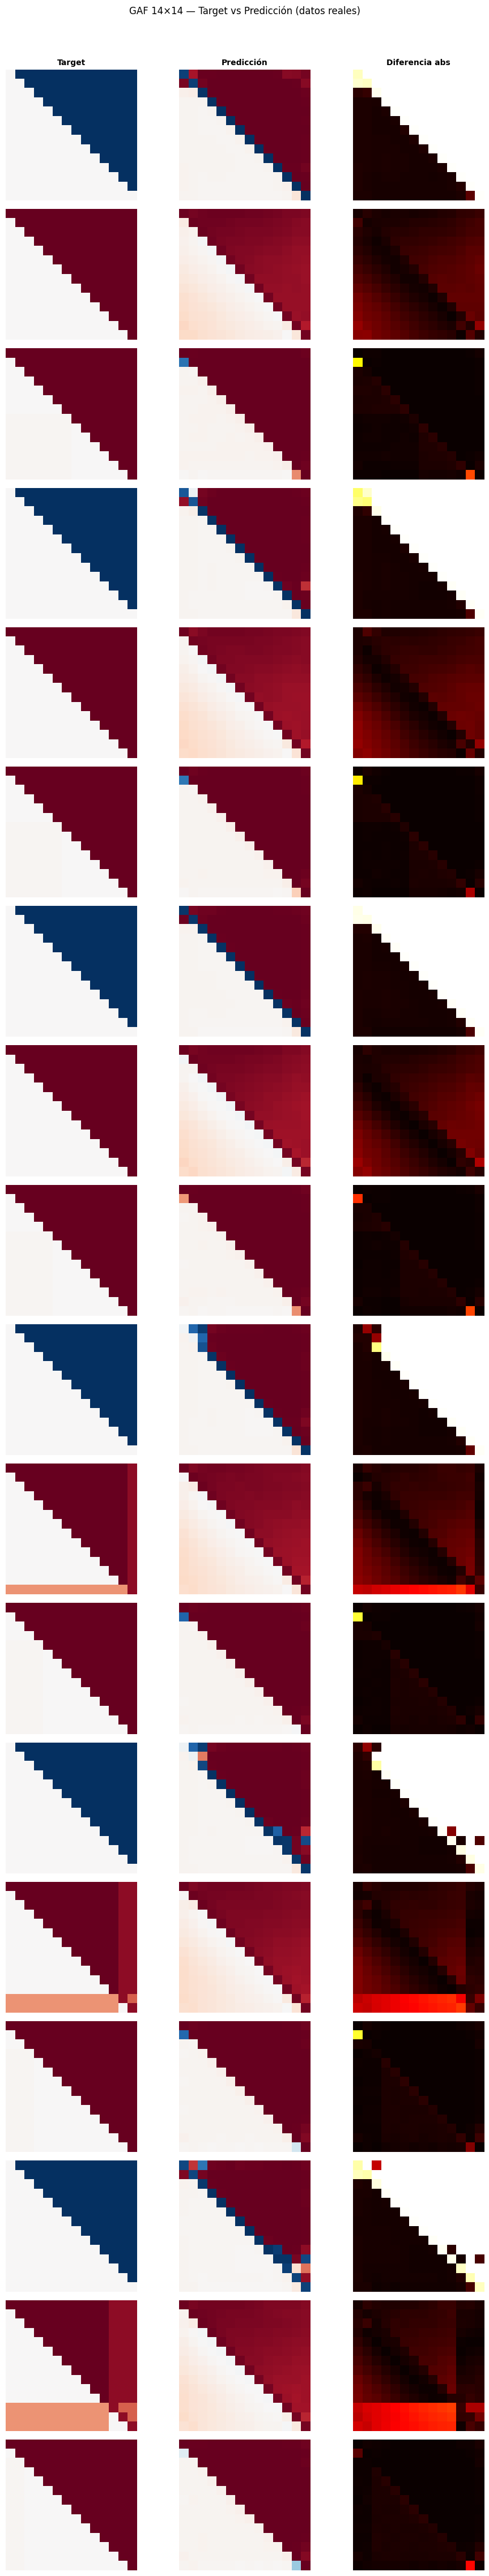

Guardado en /app/outputs/visualizations/fase6_gaf_real.png


In [10]:
def plot_gaf_comparison(targets, predictions, n_samples=4, channel_names=None):
    if channel_names is None:
        channel_names = ['Ventas', 'Stock', 'Precio']

    n_channels = targets.shape[-1]
    n_samples  = min(n_samples, len(targets))

    fig, axes = plt.subplots(
        n_samples * n_channels, 3,
        figsize=(10, n_samples * n_channels * 2.5),
    )
    if axes.ndim == 1:
        axes = axes[np.newaxis, :]

    for s in range(n_samples):
        for c in range(n_channels):
            row = s * n_channels + c
            t = targets[s, :, :, c]
            p = predictions[s, :, :, c]
            d = np.abs(t - p)

            axes[row, 0].imshow(t, cmap='RdBu_r', vmin=-1, vmax=1)
            axes[row, 1].imshow(p, cmap='RdBu_r', vmin=-1, vmax=1)
            axes[row, 2].imshow(d, cmap='hot',    vmin=0,  vmax=1)

            axes[row, 0].set_ylabel(f'M{s+1} {channel_names[c]}', fontsize=8)
            for ax in axes[row]:
                ax.axis('off')

            if row == 0:
                for ax, title in zip(axes[row], ['Target', 'Predicción', 'Diferencia abs']):
                    ax.set_title(title, fontsize=10, fontweight='bold')

    plt.suptitle(f'GAF {FORECAST_HORIZON}×{FORECAST_HORIZON} — Target vs Predicción (datos reales)', fontsize=12, y=1.01)
    plt.tight_layout()
    path = str(VISUALIZATIONS / 'fase6_gaf_real.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')

plot_gaf_comparison(targets, predictions, n_samples=6)

## 5. Diagonal: valores predichos vs reales

In [11]:
def extract_diagonal(gaf_batch: np.ndarray) -> np.ndarray:
    """
    Extrae la diagonal principal de cada imagen GAF.
    Input:  (batch, H, H, C)
    Output: (batch, H, C)
    """
    batch, h, w, c = gaf_batch.shape
    return np.stack([
        np.diagonal(gaf_batch[b], axis1=0, axis2=1).T
        for b in range(batch)
    ])  # (batch, H, C)

diag_target = extract_diagonal(targets)
diag_pred   = extract_diagonal(predictions)

print(f'Diagonal target : {diag_target.shape}  (batch, {FORECAST_HORIZON} días, 3 canales)')
print(f'Diagonal pred   : {diag_pred.shape}')

Diagonal target : (16, 14, 3)  (batch, 14 días, 3 canales)
Diagonal pred   : (16, 14, 3)


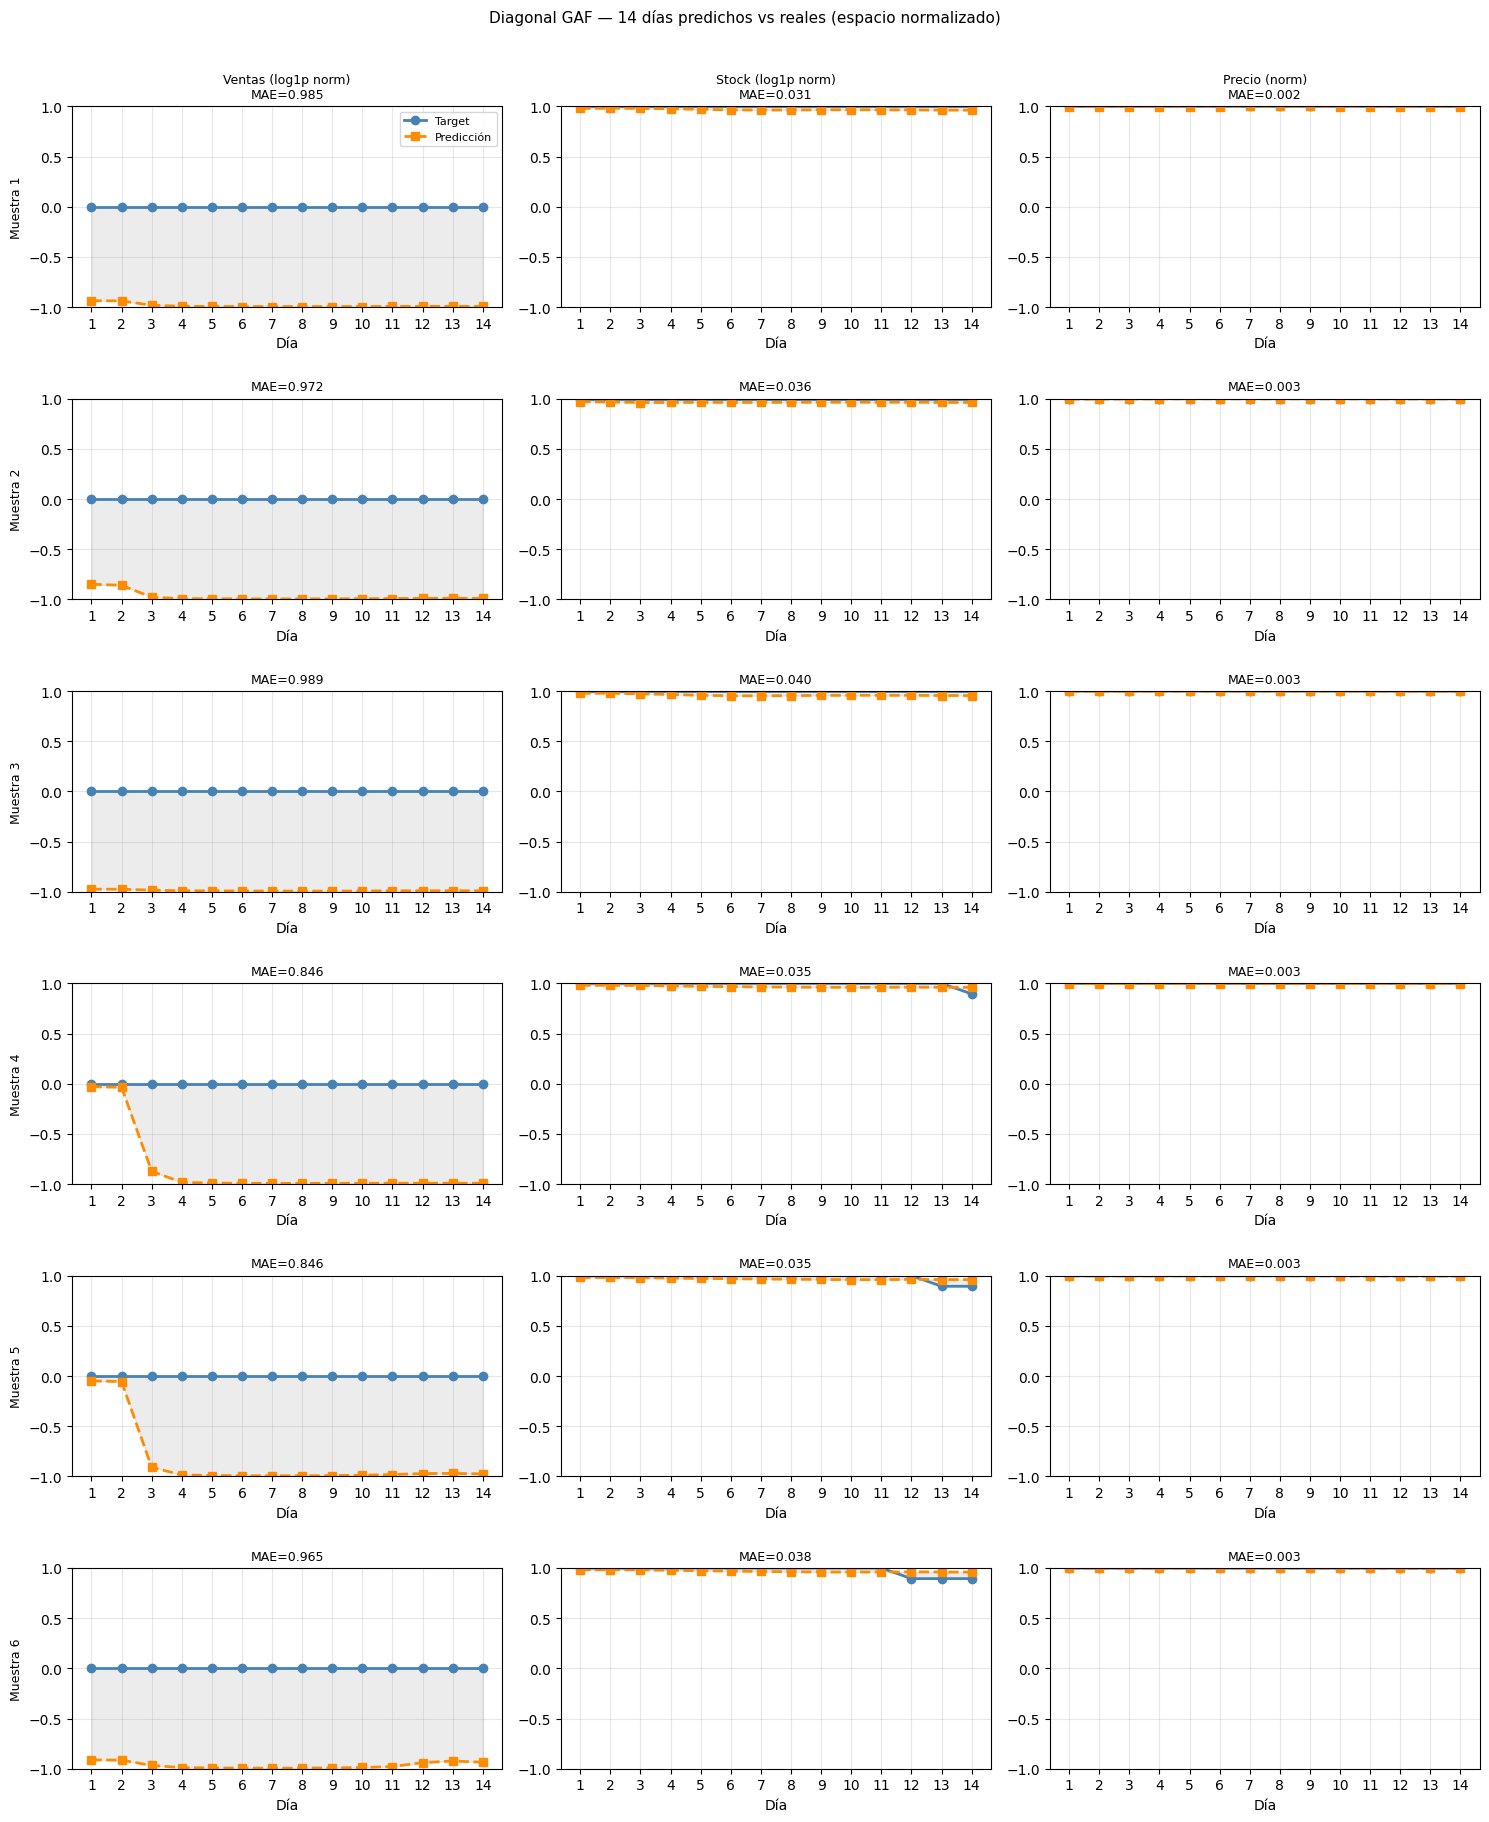

Guardado en /app/outputs/visualizations/fase6_diagonal_real.png

Nota: valores en espacio normalizado [-1,1].
Para recuperar valores reales usar invert_diagonal() de gaf/transform.py


In [12]:
def plot_diagonal(diag_target, diag_pred, n_samples=4, channel_names=None):
    if channel_names is None:
        channel_names = ['Ventas (log1p norm)', 'Stock (log1p norm)', 'Precio (norm)']

    n_ch      = diag_target.shape[-1]
    n_samples = min(n_samples, len(diag_target))
    days      = np.arange(1, diag_target.shape[1] + 1)

    fig, axes = plt.subplots(n_samples, n_ch, figsize=(5*n_ch, 3*n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for s in range(n_samples):
        for c in range(n_ch):
            ax  = axes[s, c]
            tgt = diag_target[s, :, c]
            prd = diag_pred[s,   :, c]
            mae = np.mean(np.abs(tgt - prd))

            ax.plot(days, tgt, 'o-',  color='steelblue',  label='Target',     linewidth=2)
            ax.plot(days, prd, 's--', color='darkorange', label='Predicción', linewidth=2)
            ax.fill_between(days, tgt, prd, alpha=0.15, color='gray')
            ax.set_xticks(days)
            ax.set_xlabel('Día')
            ax.grid(alpha=0.3)
            ax.set_ylim(-1,1)

            title = channel_names[c] if s == 0 else ''
            ax.set_title(f'{title}\nMAE={mae:.3f}', fontsize=9)
            if c == 0:
                ax.set_ylabel(f'Muestra {s+1}', fontsize=9)
            if s == 0 and c == 0:
                ax.legend(fontsize=8)

    plt.suptitle(f'Diagonal GAF — {FORECAST_HORIZON} días predichos vs reales (espacio normalizado)',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    path = str(VISUALIZATIONS / 'fase6_diagonal_real.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')
    print()
    print('Nota: valores en espacio normalizado [-1,1].')
    print('Para recuperar valores reales usar invert_diagonal() de gaf/transform.py')

plot_diagonal(diag_target, diag_pred, n_samples=6)

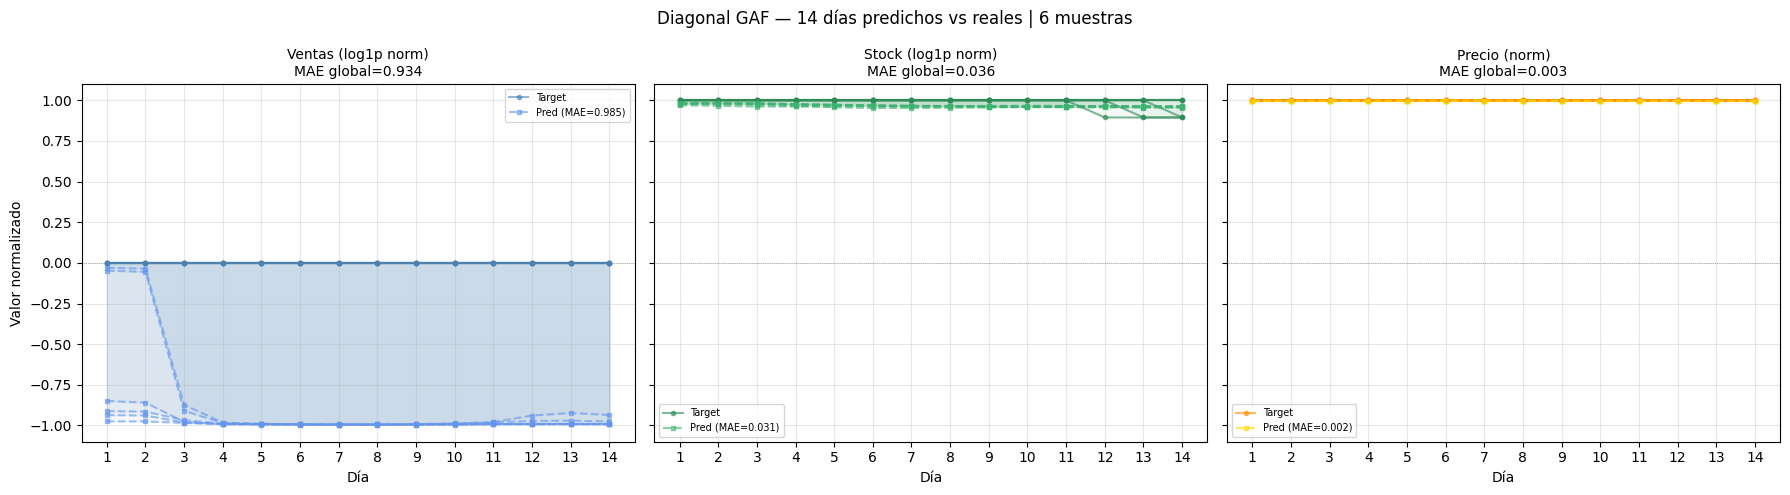

Guardado en /app/outputs/visualizations/fase6_diagonal_por_canal.png


In [13]:
def plot_diagonal_por_canal(diag_target, diag_pred, n_samples=6, channel_names=None):
    if channel_names is None:
        channel_names = ['Ventas (log1p norm)', 'Stock (log1p norm)', 'Precio (norm)']

    colores_target = ['steelblue', 'seagreen', 'darkorange']
    colores_pred   = ['cornflowerblue', 'mediumseagreen', 'gold']

    n_ch      = diag_target.shape[-1]
    n_samples = min(n_samples, len(diag_target))
    days      = np.arange(1, diag_target.shape[1] + 1)

    fig, axes = plt.subplots(1, n_ch, figsize=(6 * n_ch, 5), sharey=True)

    for c, ax in enumerate(axes):
        for s in range(n_samples):
            tgt = diag_target[s, :, c]
            prd = diag_pred[s,   :, c]
            mae = np.mean(np.abs(tgt - prd))

            ax.plot(days, tgt, 'o-',  color=colores_target[c], lw=1.5, ms=3,
                    alpha=0.6, label=f'Target' if s == 0 else None)
            ax.plot(days, prd, 's--', color=colores_pred[c],   lw=1.5, ms=3,
                    alpha=0.6, label=f'Pred (MAE={mae:.3f})' if s == 0 else f'_MAE={mae:.3f}')
            ax.fill_between(days, tgt, prd, alpha=0.05, color=colores_target[c])

        mae_global = np.mean(np.abs(diag_target[:n_samples, :, c] - diag_pred[:n_samples, :, c]))
        ax.set_title(f'{channel_names[c]}\nMAE global={mae_global:.3f}', fontsize=10)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xticks(days)
        ax.set_xlabel('Día')
        ax.axhline(0, color='gray', lw=0.5, linestyle=':')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    axes[0].set_ylabel('Valor normalizado')
    plt.suptitle(
        f'Diagonal GAF — {FORECAST_HORIZON} días predichos vs reales | {n_samples} muestras',
        fontsize=12
    )
    plt.tight_layout()
    path = str(VISUALIZATIONS / 'fase6_diagonal_por_canal.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')

plot_diagonal_por_canal(diag_target, diag_pred, n_samples=6)

## 6. Métricas globales sobre el batch de validación

══════════════════════════════════════════════════
  Métricas globales — batch de validación real
══════════════════════════════════════════════════
  MAE  (diagonal, norm.)  : 0.2637
  RMSE (diagonal, norm.)  : 0.5166
  MAPE (diagonal, norm.)  : 7.6%
  SSIM (imagen 14×14)       : 0.7359 ± 0.0425
══════════════════════════════════════════════════


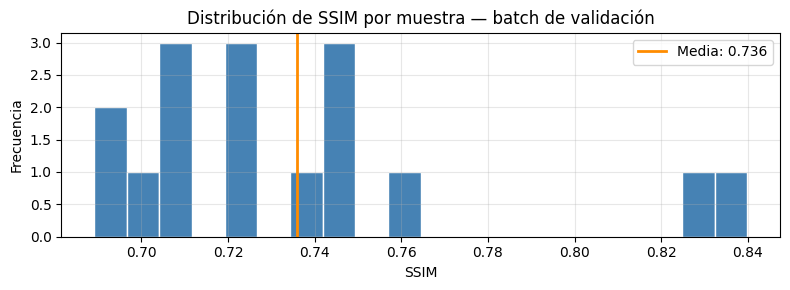

In [14]:
t = diag_target.astype(np.float32)
p = diag_pred.astype(np.float32)

mae  = np.mean(np.abs(t - p))
rmse = np.sqrt(np.mean((t - p) ** 2))

mask = np.abs(t) > 0.01
mape = np.mean(np.abs((t[mask] - p[mask]) / t[mask])) * 100 if mask.any() else float('nan')

t_01 = (targets.astype('float32') + 1) / 2
p_01 = (predictions.astype('float32') + 1) / 2
ssim_vals = [
    tf.image.ssim(
        t_01[i:i+1], p_01[i:i+1],
        max_val=1.0, filter_size=3, filter_sigma=0.5
    ).numpy()[0]
    for i in range(len(targets))
]
ssim_mean = np.mean(ssim_vals)
ssim_std  = np.std(ssim_vals)

print('══════════════════════════════════════════════════')
print('  Métricas globales — batch de validación real')
print('══════════════════════════════════════════════════')
print(f'  MAE  (diagonal, norm.)  : {mae:.4f}')
print(f'  RMSE (diagonal, norm.)  : {rmse:.4f}')
print(f'  MAPE (diagonal, norm.)  : {mape:.1f}%' if not np.isnan(mape) else '  MAPE: N/A')
print(f'  SSIM (imagen {FORECAST_HORIZON}×{FORECAST_HORIZON})       : {ssim_mean:.4f} ± {ssim_std:.4f}')
print('══════════════════════════════════════════════════')

# Distribución de SSIM por muestra
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ssim_vals, bins=20, color='steelblue', edgecolor='white')
ax.axvline(ssim_mean, color='darkorange', linewidth=2, label=f'Media: {ssim_mean:.3f}')
ax.set_title('Distribución de SSIM por muestra — batch de validación')
ax.set_xlabel('SSIM')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(VISUALIZATIONS / 'fase6_ssim_dist.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Análisis por canal

Métricas por canal (diagonal):
  Canal           MAE     RMSE
  ----------------------------
  Ventas       0.7113   0.8795
  Stock        0.0774   0.1647
  Precio       0.0023   0.0026


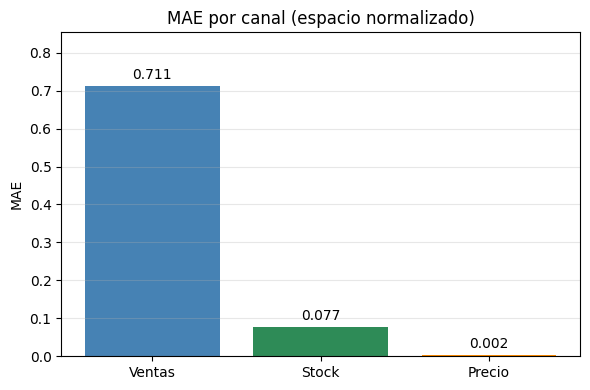

In [15]:
channel_names = ['Ventas', 'Stock', 'Precio']

print('Métricas por canal (diagonal):')
print(f'  {"Canal":<10} {"MAE":>8} {"RMSE":>8}')
print('  ' + '-'*28)
for c, name in enumerate(channel_names):
    mae_c  = np.mean(np.abs(t[:,:,c] - p[:,:,c]))
    rmse_c = np.sqrt(np.mean((t[:,:,c] - p[:,:,c])**2))
    print(f'  {name:<10} {mae_c:>8.4f} {rmse_c:>8.4f}')

# Barplot MAE por canal
maes = [np.mean(np.abs(t[:,:,c] - p[:,:,c])) for c in range(3)]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(channel_names, maes, color=['steelblue', 'seagreen', 'darkorange'])
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title('MAE por canal (espacio normalizado)')
ax.set_ylabel('MAE')
ax.set_ylim(0, max(maes) * 1.2)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(str(VISUALIZATIONS / 'fase6_mae_canal.png'), dpi=120, bbox_inches='tight')
plt.show()

## Resumen final

In [16]:
best_ssim_total = max(max(ssim1) if ssim1 else 0, max(ssim2) if ssim2 else 0)

print('══════════════════════════════════════════════════')
print('  FASE 6 — Resumen de resultados')
print('══════════════════════════════════════════════════')
print(f'  Mejor SSIM val global   : {best_ssim_total:.4f}')
print(f'  SSIM en batch viz       : {ssim_mean:.4f} ± {ssim_std:.4f}')
print(f'  MAE diagonal (norm.)    : {mae:.4f}')
print()
if best_ssim_total >= 0.7:
    print('  ✅ Objetivo SSIM > 0.7 alcanzado')
elif best_ssim_total >= 0.5:
    print('  🟡 SSIM entre 0.5 y 0.7 — modelo útil, hay margen de mejora')
else:
    print('  ⚠️  SSIM < 0.5 — considerar más épocas o más combinaciones')
print()
print('  Imágenes guardadas en outputs/visualizations/')
print('    - fase6_curvas.png')
print('    - fase6_lr.png')
print('    - fase6_gaf_real.png')
print('    - fase6_diagonal_real.png')
print('    - fase6_ssim_dist.png')
print('    - fase6_mae_canal.png')
print('══════════════════════════════════════════════════')

══════════════════════════════════════════════════
  FASE 6 — Resumen de resultados
══════════════════════════════════════════════════
  Mejor SSIM val global   : 0.6507
  SSIM en batch viz       : 0.7359 ± 0.0425
  MAE diagonal (norm.)    : 0.2637

  🟡 SSIM entre 0.5 y 0.7 — modelo útil, hay margen de mejora

  Imágenes guardadas en outputs/visualizations/
    - fase6_curvas.png
    - fase6_lr.png
    - fase6_gaf_real.png
    - fase6_diagonal_real.png
    - fase6_ssim_dist.png
    - fase6_mae_canal.png
══════════════════════════════════════════════════
